In [1]:
import json
import jieba

output_file = '/workspace2/chiwu/works/critc_extraction/sentence_level_result/sentence_level_result.jsonl'

with open(output_file, 'r', encoding='utf8') as f_in:
    items_list = json.load(f_in)  # 此时 items_list 是列表


texts = [item['item'] for item in items_list]

In [2]:
texts[0]

'**2024Q3 GMV占比异常低**：2024Q3 GMV仅388.25万元，占比9.69%，远低于其他季度（如2024Q2占比46.94%），可能存在经营异常或季节性波动未解释，需关注（一般负向）。[风险缺失]'

In [3]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("/workspace2/chiwu/models/Qwen3-Embedding-8B")
document_embeddings = model.encode(texts)

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-07-08 15:44:27,502 - root - INFO - lm_eval is not installed, GPTQ may not be usable
2025-07-08 15:44:27,746 - datasets - INFO - PyTorch version 2.4.0+cu121 available.
2025-07-08 15:44:28,227 - sentence_transformers.SentenceTransformer - INFO - Use pytorch device_name: cuda
2025-07-08 15:44:28,228 - sentence_transformers.SentenceTransformer - INFO - Load pretrained SentenceTransformer: /workspace2/chiwu/models/Qwen3-Embedding-8B
2025-07-08 15:44:28,287 - sentence_transformers.SentenceTransformer - WARNING - No sentence-transformers model found with name /workspace2/chiwu/models/Qwen3-Embedding-8B. Creating a new one with mean pooling.


ValueError: The checkpoint you are trying to load has model type `qwen3` but Transformers does not recognize this architecture. This could be because of an issue with the checkpoint, or because your version of Transformers is out of date.

In [ ]:
document_embeddings.shape

(6860, 2560)

In [56]:
# t-sne降维可视化
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# X 是你的(6860, 2560)向量，若是torch/其他类型，先 .cpu().numpy() 转为numpy数组
X = document_embeddings # 已有的embedding，形状(6860, 2560)
# 比如如果你保存成了np数组:
# X = np.load('qwen3_embeddings.npy')

# 建议先归一化/标准化
from sklearn.preprocessing import StandardScaler
X_norm = StandardScaler().fit_transform(X)

# t-SNE降到2维
tsne = TSNE(n_components=2, random_state=42, perplexity=50, n_iter=1000)
X_tsne = tsne.fit_transform(X_norm)   # (6860,2)

In [ ]:
X_tsne.shape

(6860, 2)

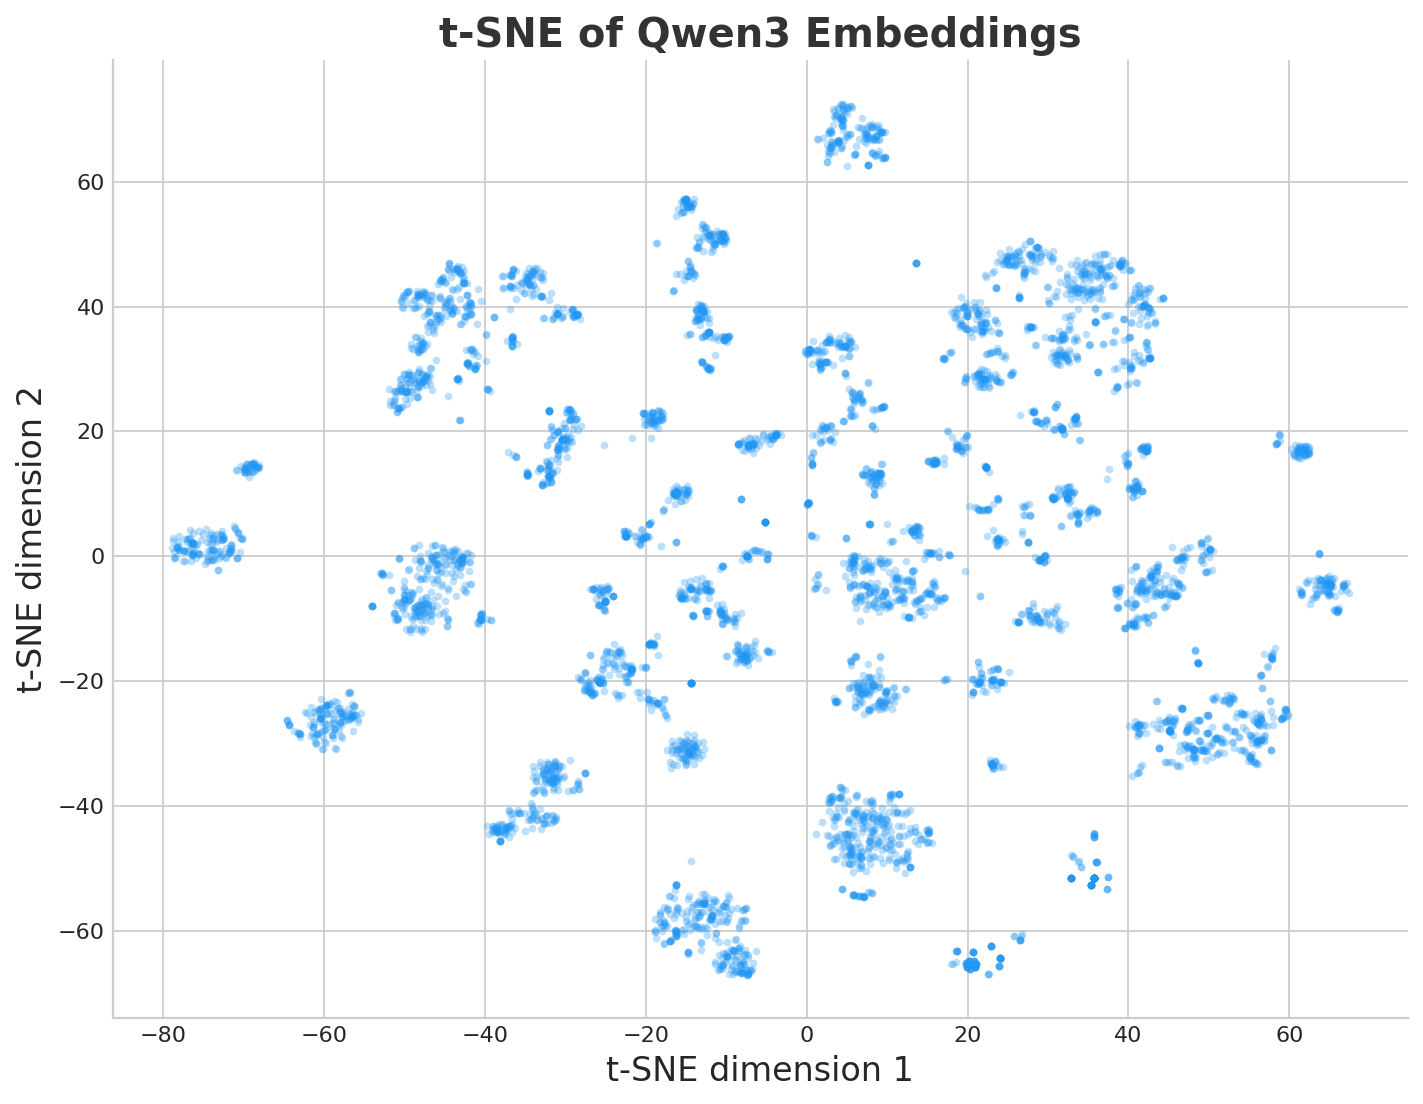

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# 美观可视化
plt.style.use('seaborn-v0_8-whitegrid')  # 美观主题
fig, ax = plt.subplots(figsize=(9, 7), dpi=160)

sc = ax.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c="#2196f3",
    alpha=0.30,
    s=12,
    linewidths=0,
    rasterized=True
)

ax.set_title("t-SNE of Qwen3 Embeddings", fontsize=18, fontweight='bold', color="#333333")
ax.set_xlabel("t-SNE dimension 1", fontsize=15)
ax.set_ylabel("t-SNE dimension 2", fontsize=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/workspace2/chiwu/works/critc_extraction/qwen3-8b-embedding_tsne.pdf')
plt.show()


In [8]:
from sklearn.decomposition import PCA
import hdbscan

In [61]:
x_pca = PCA(n_components=100, random_state=42).fit_transform(document_embeddings)
clusterer = hdbscan.HDBSCAN(min_cluster_size=20, metric='euclidean')
labels = clusterer.fit_predict(x_pca)

In [11]:
labels.shape

(6860,)

In [62]:
# 查看类别数量
classes = set(labels)
classes

{-1,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43}

In [64]:
for l in classes:
    idxs = [i for i, lbl in enumerate(labels) if lbl == l]
    print(f"\n--- label {l} 有 {len(idxs)} 条文本 ---")
    for idx in idxs[:10]:  # 只显示前10个
        print(texts[idx])


--- label 0 有 143 条文本 ---
**流动资产周转率**：3.79次（3~6次中性区间下限），资金效率偏低，中性偏负向。—— 流动资产周转率3.79次在3-6次之间，应为中性。[标准错误]
**流动资产周转率**：3次（3~6次中性区间下限），资金效率一般。—— 流动资产周转率3次属于中性区间下限，应为中性，不应归为负向。[标准错误]
**流动资产周转率**：3次（3~6次中性区间下限），资金效率偏低。—— 3次属于中性区间下限，应为中性。[标准错误]
**流动资产周转率**：3次（3~6次中性区间下限），资金效率偏低。—— 流动资产周转率3次属于中性区间，不应判定为负向。[标准错误]
**流动资产周转率**：3次（3~6次中性区间下限），资金效率偏低。—— 流动资产周转率3次属于3~6次中性区间，应为中性。[标准错误]
流动资产周转率：3.1次（3~6次中性区间下限），资金效率偏低。—— 流动资产周转率3.1次在3-6次之间，应为中性。[标准错误]
**流动资产周转率**：3.13次（3~6次中性区间下限），资金效率偏低。—— 流动资产周转率3.13次属于中性区间，不应判定为负向。[标准错误]
**流动资产周转率**：4.09次（3~6次中性区间下限），资金效率中等偏弱。—— 4.09次在3-6次区间内，应为中性。[标准错误]
**流动资产周转率4.46次**（<6次），效率偏低，应为中性偏负向。[风险缺失]
**流动资产周转率**：3次（3~6次中性区间下限），资金效率偏低。——周转率处在中性区间内，为中性。 [标准错误]

--- label 1 有 45 条文本 ---
**流动资产周转率缺失**：无法评估资金效率，中性偏负向。——流动资产周转率缺失属于中性。 [标准错误]
**流动资产周转率缺失**：无法评估资金效率。—— 流动资产周转率缺失属于中性。[标准错误]
**流动资产周转率缺失**：缺失数据，无法评估企业财务状况，需警惕风险，一般负向。[风险缺失]
**流动资产周转率缺失**：无法评估资金效率，中性偏负。—— 缺失应为中性，不应直接判定为负向。[标准错误]
**流动资产周转率缺失**：无法评估资金效率（一般负向）。—— 标准中流动资产周转率缺失未作为指标，应为中性。[标准错误]
**流动资产周转率缺失**：无法评估资金效率（一

In [129]:
# 使用BERTTOPIC方法
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from hdbscan import HDBSCAN
# 使用UMAP进行降维
from umap import UMAP
import jieba
def tokenize_zh(text):
    words = jieba.lcut(text)
    return words

umap_model = UMAP(
    n_neighbors=15,        # 邻域样本数。越大保全全局结构，越小突出局部特征。小＝类多碎片，大＝类更粗。
    n_components=10,        # 降到几维空间。越低降损越大，通常5-20维足够。太低会损失信息，太高对后续HDBSCAN也有影响。
    min_dist=0.0,          # 最小距离，越小点更紧凑/更分散，越大类更容易融合
    metric='cosine'        # 距离度量方式。和embedding兼容性强：'cosine'/'euclidean'常见
)

hdbscan_model = HDBSCAN(
    min_cluster_size=15,              # 一个簇的最小样本数（建议3~20调节）。大＝只聚大类，小＝碎片类更多
    metric='euclidean',                  # 距离度量。"cosine"和"euclidean"都可尝试
    cluster_selection_method='eom',   # 'eom'(默认)=更自然，'leaf'=更碎
    prediction_data=True,              # 输出预测用数据（留着就好）
)

vectorizer_model = CountVectorizer(
    min_df=10,              # 至少多少文档才保留该词，防止低频干扰。一般1~10。大＝主题关键词更泛。
    tokenizer=tokenize_zh   # 中文自定义分词函数
)
topic_model = BERTopic(
    nr_topics="auto",             # 自动主题数（聚类类别多少）
    language='chinese',           # 关键影响分词，业务语言
    embedding_model=model,        # 你的embedding提取器（如Qwen/Deepseek/通用类等）
    umap_model=umap_model,        
    hdbscan_model=hdbscan_model,  
    vectorizer_model=vectorizer_model
)
topics, probs = topic_model.fit_transform(texts)

In [106]:
topic_model.reduce_topics(texts, nr_topics=40)
# topics = topic_model.topics_
# probs = topic_model.probabilities_

In [118]:
topic_model.get_topic_info()[:]

,Topic,Count,Name,Representation,Representative_Docs
0,-1,499,-1_授信_万元_机构_，,"[授信, 万元, 机构, ，, *, （, ）, 类, 。, ]",[**同业认可度**：单家最高授信300万元（银行对公贷款），远超月均GMV（235万元），...
1,0,498,0_授信_类_万元_月均,"[授信, 类, 万元, 月均, 银行, gmv, 信用, 抵押, *, /]",[**同业认可度高**：单家最高授信231.7万元（银行抵押类），远超月均GMV（71.89...
2,1,459,1_近_同比_月_12,"[近, 同比, 月, 12, 销售, /, 3, 6, 超过, 严重]",[**销售趋势**：近3月/6月销售同比分别下滑33.92%/19.78%（近12月仍上升3...
3,2,389,2_短期_压力_贷款_情况,"[短期, 压力, 贷款, 情况, 占, 信用, 类, 需, 负债, 关注]",[短期偿债压力：近3个月200万元信用类贷款到期（合作年限仅0.8年），需关注续贷情况（中性...
4,3,371,3_合作_集中度_年_30%,"[合作, 集中度, 年, 30%, 稳定性, 2, 大, 比, *, 占]",[**下游集中度**：第一大下游江苏地华实业占比16.35%（虽未达30%但合作仅3年），需...
5,4,307,4_已_金额_影响_小,"[已, 金额, 影响, 小, 较, 记录, 未, ，, 偏负, 且]",[涉诉记录：武汉创恒世纪激光科技2023年被告侵权纠纷（标的2.9万元，已结案），影响较小，...
6,5,296,5_机构_余额_贷款_较,"[机构, 余额, 贷款, 较, 小, 融资, 数, 根据, *, 存在]",[**非银机构存在**：1家非银机构贷款（余额8.27万元），融资成本略高，轻微负向。—— ...
7,6,272,6_行业_风险_属于_关注,"[行业, 风险, 属于, 关注, 需, 低, 高风险, 明确, 列为, 其他]",[**行业风险**：电动车制造行业（政策敏感且竞争激烈），需关注行业波动影响。—— 行业代码...
8,7,262,7_时间_比例_企业_年,"[时间, 比例, 企业, 年, 50%, 10%, 负, 向, 在, 对]",[企业稳定性：企业成立时间超12年（2012年成立），法人持股40%（10%~50%区间），...
9,8,204,8_数据_gmv_申请_不足,"[数据, gmv, 申请, 不足, 个, <, 年, 万, *, 月]",[经营数据新鲜度：数据截止日期距离调查日期为1月（<3个月），但最近GMV数据为2023Q3...


In [119]:
topic_model.visualize_topics()

In [120]:
topic_model.visualize_barchart()
# 主要用于展示每个聚类主题的“关键词条形图”，理解聚出来的每个主题都在说什么、由哪些高频词汇组成。

In [121]:
# visualize_hierarchy() 是 BERTopic 用于主题分层关系（也称“主题树”或者“主题聚合热图”）的可视化工具。

# 它的目的是：

# 展示 BERTopic 聚出来的各个主题（topic）之间的层次结构、相似度和归并关系。
# 类似于层次聚类（Hierarchical Clustering）的树状图（dendrogram），让你看到：
# 哪些小主题比较像，可以合并成大主题
# 哪些主题很独立
# 主题之间的距离/亲疏关系
topic_model.visualize_hierarchy()

In [122]:
topic_model.visualize_documents(texts, embeddings = document_embeddings)

In [123]:
from collections import defaultdict

topic2docs = defaultdict(list)
for idx, topic in enumerate(topics):
    topic2docs[topic].append(idx)

In [124]:
import pandas as pd
# texts: 你的原始文本列表; topics: BERTopic输出的主题编号列表
df = pd.DataFrame({'text': texts, 'topic': topics})

with pd.ExcelWriter('/workspace2/chiwu/works/critc_extraction/bertopic_by_topic.xlsx') as writer:
    for topic_id in set(topics):
        df_topic = df[df['topic'] == topic_id]
        df_topic.to_excel(writer, sheet_name=f"topic_{topic_id}", index=False)

In [125]:
print(f"类别数量{len(set(topics))}")

类别数量54


一、常见聚类质量评估指标说明
1. 轮廓系数（Silhouette Score）
定义：对于每个样本，计算其和本簇内其他样本的平均距离 a，以及与最近其他簇所有样本的平均距离 b，轮廓系数 s = (b - a) / max(a, b)
取值范围：[-1, 1]，越接近1越好，0表示重叠，<0表示样本被分错簇了。
优点：简单直观，广泛应用于找“最佳类数K”。
适用性：对KMeans这种“所有点都有label”的聚类很好，对带噪点的算法（如HDBSCAN）时要注意（-1类要排除）。
2. Calinski-Harabasz Index（CH指数，方差比准则）
定义：类间离散度 / 类内离散度。数值越大聚类效果越好。
适用性：无需归一到[0,1]，只需越大越好。适合快速对比多分组。
3. Davies-Bouldin Index（DB指数）
定义：每个簇的类内聚合度与与最近他簇的分离度比值的平均。越小越好。

In [130]:
import numpy as np
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# 1. 获得降维向量（假如topic_model用的是你自定义的umap_model，聚类时一定调用了umap.transform）
# NOTE:
# - BERTopic2.0及以上可以用 topic_model.umap_model.transform(document_embeddings)
# - 如果用get_document_info()后有'representation'字段也可用
embeddings_umap = topic_model.umap_model.transform(document_embeddings)  # 必须和聚类时一致

labels = np.array(topics)  # 聚类标签（int类型）

# 2. 去除噪声点
mask = labels != -1    # -1 是HDBSCAN噪声类，不能参与评估
labels_eval = labels[mask]
vectors_eval = embeddings_umap[mask]

# 3. 计算常用指标
silhouette = silhouette_score(vectors_eval, labels_eval)
ch_score = calinski_harabasz_score(vectors_eval, labels_eval)
db_score = davies_bouldin_score(vectors_eval, labels_eval)

print(f"Silhouette Score: {silhouette:.3f}")
print(f"Calinski-Harabasz Index: {ch_score:.2f}")
print(f"Davies-Bouldin Index: {db_score:.3f}")

Silhouette Score: 0.530
Calinski-Harabasz Index: 1878.64
Davies-Bouldin Index: 0.805
